In [31]:
from mlp.MLP import standardMLP
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

In [32]:
def R2(preds, targets):
    """
    Coefficient of Determination (R²).
    Note: R² can be negative if predictions are worse than the mean baseline.
    R² = 1 - (SS_res / SS_tot)
    """
    pred_mean = torch.mean(preds, dim=0, keepdim=True)
    target_mean = torch.mean(targets, dim=0, keepdim=True)
    SS_res = torch.sum((targets - preds)**2, dim=0)
    SS_tot = torch.sum((targets - target_mean)**2, dim=0)
    r2_score = 1 - (SS_res / (SS_tot + 1e-8))
    return torch.nan_to_num(r2_score)


seed = 1
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

function_set = [
    ("x",lambda x: x[:]),
    ("x**2",lambda x: x[:]**2),
    ("x**3",lambda x: x[:]**3),
    ("x**4",lambda x: x[:]**4),
    ("x**5",lambda x: x[:]**5),
    ("1/x",lambda x: 1/(x[:] + 1e-8)),
    ("1/x**2",lambda x: 1/(x[:]**2 + 1e-8)),
    ("1/x**3",lambda x: 1/(x[:]**3 + 1e-8)),
    ("1/x**4",lambda x: 1/(x[:]**4 + 1e-8)),
    ("1/x**5",lambda x: 1/(x[:]**5 + 1e-8)),
    ("sin(x)",lambda x: torch.sin(x[:])),
    ("cos(x)",lambda x: torch.cos(x[:])),
    ("sin(2x)",lambda x: torch.sin(2*x[:])),
    ("cos(2x)",lambda x: torch.cos(2*x[:])),
    ("sin(x**2)",lambda x: torch.sin(x[:]**2)),
    ("cos(x**2)",lambda x: torch.cos(x[:]**2)),
    ("tan(x)",lambda x: torch.tan(x[:])),
    ("exp(x)",lambda x: torch.exp(x[:])),
    ("sqrt(x)",lambda x: torch.sqrt(torch.abs(x[:]))),
    ("log(x)",lambda x: torch.log(torch.abs(x[:])+1e-8)),
    ("exp(-x**2)",lambda x: torch.exp(-x[:]**2))
]
function = (lambda x: -996 * x[:]**3 + 12.8 * x[:]**2 -24.6 * x[:] -0.115)
X_all = torch.randn(2200, 1)
y_all = function(X_all)
X_train = X_all[:2000]
y_train = y_all[:2000]
X_test = X_all[2000:]
y_test = y_all[2000:]
dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# # Initialize KAN and fit the model

model = standardMLP([1,50,50,1])

In [33]:
model.fit(dataset=dataset, steps=75, lr=1e-2, batch_size=32, early_stop=None, weight_decay=0, seed=seed);

In [34]:
# X_train = torch.randn(2000, 1)
# y_train = (lambda x: x[:]**4)(X_train)
# X_test = torch.randn(200, 1)
# y_test = (lambda x: x[:]**4)(X_test)
# dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# model = standardMLP([1,3,1])
# model.fit(dataset=dataset, steps=300, lr=1e-3, batch_size=64, early_stop=None, weight_decay=0);

# X_train = torch.randn(2000, 1)
# y_train = (lambda x: x[:]**5)(X_train)
# X_test = torch.randn(200, 1)
# y_test = (lambda x: x[:]**5)(X_test)
# dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# model = standardMLP([1,3,1])
# model.fit(dataset=dataset, steps=300, lr=1e-3, batch_size=64, early_stop=None, weight_decay=0);

In [35]:
y_pred_test = model(dataset['test_input'])
y_pred_train = model(dataset['train_input'])
mse_test = torch.nn.MSELoss()(y_pred_test, dataset['test_label']).item()
mse_train = torch.nn.MSELoss()(y_pred_train, dataset['train_label']).item()
R2_score_kan = R2(y_pred_test, dataset['test_label']).item()
print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}, R² Score: {R2_score_kan:.4f}")

Train MSE: 46573.9102, Test MSE: 16764.6953, R² Score: 0.9991


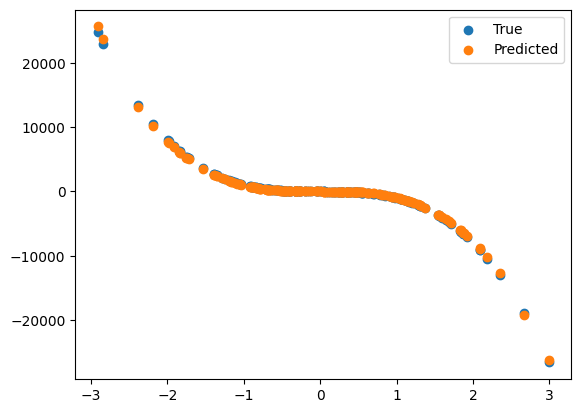

In [36]:
y_pred = model(dataset['test_input'])
plt.scatter(dataset['test_input'].numpy(), y_test.numpy(), label='True')
plt.scatter(dataset['test_input'].numpy(), y_pred.detach().numpy(), label='Predicted')
# plt.scatter(dataset['train_input'].numpy(), dataset['train_label'].numpy(), label='Train Data', alpha=0.5)
plt.legend()